## Module 1 

### Question 1 - Customer Sales Analysis
 Load a CSV file containing sales transactions using Pandas. Clean missing values, compute total revenue by product category, identify the top 10 customers, and visualize monthly sales using Matplotlib.
Expected Deliverables: Python code, cleaned dataset, summary statistics, and two plots.


- Dataset - https://archive.ics.uci.edu/dataset/502/online+retail+ii

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
plt.style.use("default")

### 2. Load the Dataset

In [7]:
# Replace with your CSV file path
file_path = ".\online+retail+ii\online_retail_II.xlsx"

df = pd.read_excel(file_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### 3. Initial Data Exploration

In [ ]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [10]:
print("\nMissing Values:")
print(df.isnull().sum())




Missing Values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [11]:
print("\nSummary Statistics:")
df.describe(include="all")


Summary Statistics:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,525461.0,525461,522533,525461.000000,525461,525461.000000,417534.000000,525461
unique,28816.0,4632,4681,NaN,NaN,NaN,NaN,40
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,675.0,3516,3549,NaN,NaN,NaN,NaN,485852
mean,NaN,NaN,NaN,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478,NaN
min,NaN,NaN,NaN,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2010-03-21 12:20:00,1.250000,13983.000000,NaN
50%,NaN,NaN,NaN,3.000000,2010-07-06 09:51:00,2.100000,15311.000000,NaN
75%,NaN,NaN,NaN,10.000000,2010-10-15 12:45:00,4.210000,16799.000000,NaN
max,NaN,NaN,NaN,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,NaN


### 4. Data Cleaning

In [ ]:
# remove cancelled orders
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Check missing values
print(df.isnull().sum())

# Remove rows with missing CustomerID
df = df.dropna(subset=["Customer ID"])

# Fill missing descriptions
df["Description"] = df["Description"].fillna("Unknown Product")

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107560
Country             0
dtype: int64


In [20]:
df["Customer ID"] = df["Customer ID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]

df["Revenue"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


### 5. Save Cleaned Dataset

In [22]:
cleaned_file = ".\online+retail+ii\cleaned_sales_transactions.csv"

df.to_csv(cleaned_file, index=False)

print(f"Cleaned dataset saved to: {cleaned_file}")

Cleaned dataset saved to: .\online+retail+ii\cleaned_sales_transactions.csv


### 6. Summary Statistics

In [25]:
summary_stats = {
    "Total Transactions": len(df),
    "Unique Customers": df["Customer ID"].nunique(),
    "Unique Products": df["StockCode"].nunique(),
    "Total Revenue (£)": round(df["Revenue"].sum(), 2),
    "Average Order Value (£)": round(df["Revenue"].mean(), 2)
}

pd.DataFrame(summary_stats.items(),
             columns=["Metric", "Value"])

,Metric,Value
0,Total Transactions,407664.00
1,Unique Customers,4312.00
2,Unique Products,4017.00
3,Total Revenue (£),8832003.27
4,Average Order Value (£),21.66


### 7. Revenue by Product Category

In [26]:
category_revenue = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

category_revenue.head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER     151624.31
REGENCY CAKESTAND 3 TIER               143893.35
Manual                                  98560.64
ASSORTED COLOUR BIRD ORNAMENT           70493.83
JUMBO BAG RED RETROSPOT                 51759.30
POSTAGE                                 48741.08
ROTATING SILVER ANGELS T-LIGHT HLDR     40186.65
PAPER CHAIN KIT 50'S CHRISTMAS          36933.50
PARTY BUNTING                           35035.90
EDWARDIAN PARASOL NATURAL               34044.75
Name: Revenue, dtype: float64

In [28]:
top_customers = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

Customer ID
18102    349164.35
14646    248396.50
14156    196566.74
14911    152147.57
13694    131443.19
17511     84541.17
15061     83284.38
16684     80489.21
16754     65500.07
17949     60117.60
Name: Revenue, dtype: float64

In [29]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = (
    df.groupby("YearMonth")["Revenue"]
      .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales.head()

YearMonth
2009-12    686654.160
2010-01    557319.062
2010-02    506371.066
2010-03    699608.991
2010-04    594609.192
Name: Revenue, dtype: float64

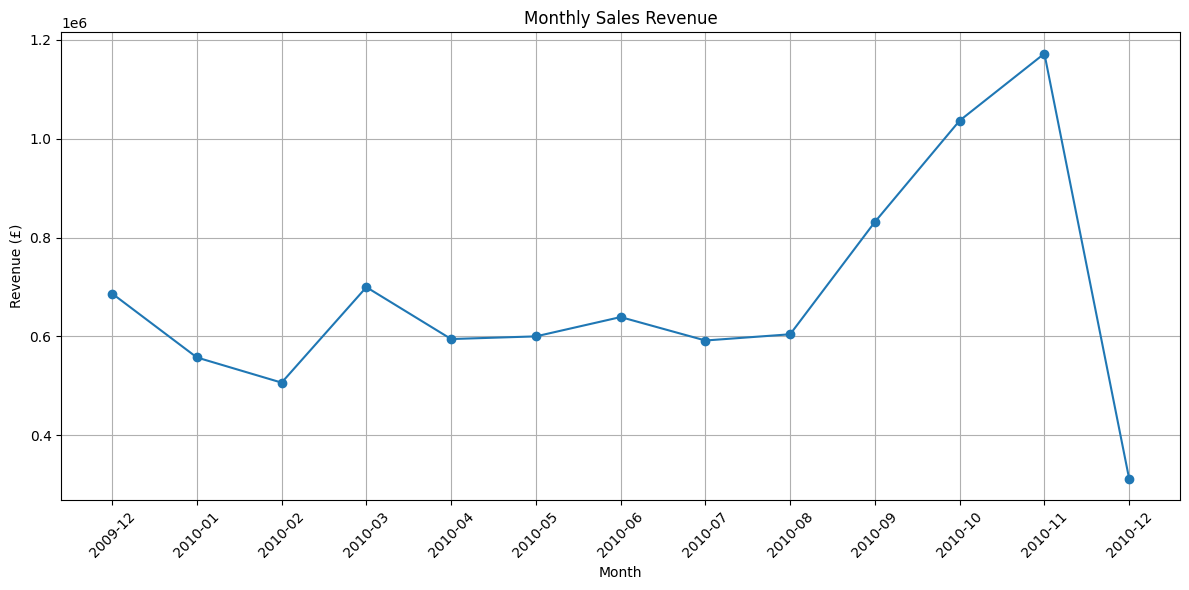

In [30]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

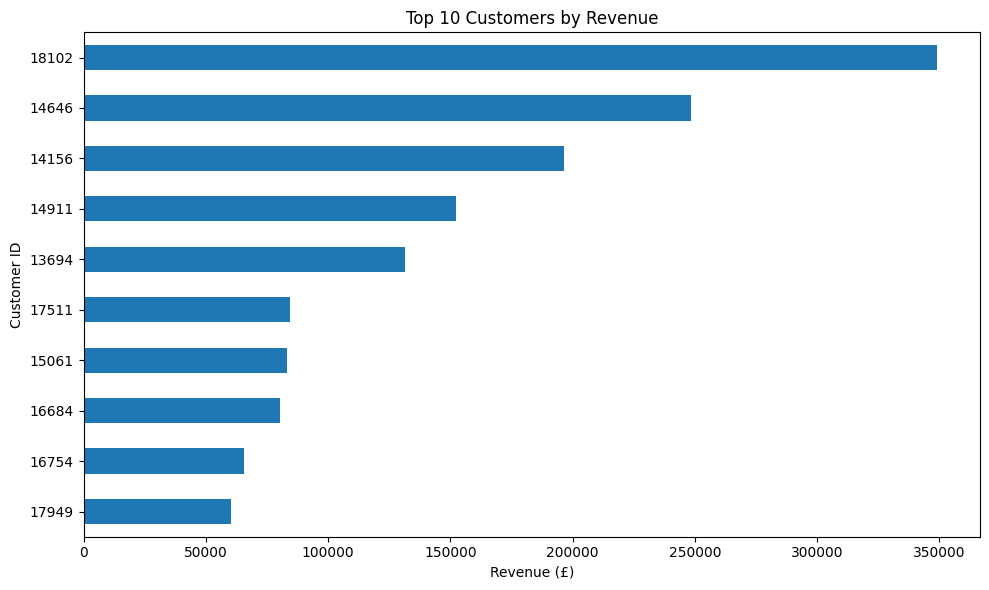

In [31]:
plt.figure(figsize=(10, 6))

top_customers.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()